Revenue Leakage Analysis: Finding $4.4M in Hidden Losses
--

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


Phase 1 Loading The Data and Basic Understanding
---

In [2]:
df = pd.read_csv("synthetic.csv")

In [3]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96


In [4]:
#checkingg the dataset shape
print(df.shape)

(100000, 13)


In [5]:
#the  columns in the dataset
print(df.columns)

Index(['order_id', 'customer_id', 'product_category', 'product_price',
       'quantity', 'order_date', 'region', 'payment_method', 'delivery_days',
       'is_returned', 'customer_rating', 'discount_percent', 'revenue'],
      dtype='object')


Phase 2 – Data Cleaning
-

In [6]:
print(df.dtypes)

order_id              int64
customer_id          object
product_category     object
product_price       float64
quantity              int64
order_date           object
region               object
payment_method       object
delivery_days         int64
is_returned           int64
customer_rating     float64
discount_percent      int64
revenue             float64
dtype: object


In [7]:
#checking the number of missing values
print(df.isnull().sum())

order_id            0
customer_id         0
product_category    0
product_price       0
quantity            0
order_date          0
region              0
payment_method      0
delivery_days       0
is_returned         0
customer_rating     0
discount_percent    0
revenue             0
dtype: int64


In [8]:
#checking the total number of dupliactes in the dataset
print(df.duplicated().sum())

0


In [9]:
print(df['order_id'].duplicated().sum())

0


In [10]:
df['order_date'] = df['order_date'].astype('datetime64[ns]')

In [11]:
df.dtypes

order_id                     int64
customer_id                 object
product_category            object
product_price              float64
quantity                     int64
order_date          datetime64[ns]
region                      object
payment_method              object
delivery_days                int64
is_returned                  int64
customer_rating            float64
discount_percent             int64
revenue                    float64
dtype: object

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [13]:
df.dtypes

order_id                     int64
customer_id                 object
product_category            object
product_price              float64
quantity                     int64
order_date          datetime64[ns]
region                      object
payment_method              object
delivery_days                int64
is_returned                  int64
customer_rating            float64
discount_percent             int64
revenue                    float64
dtype: object

In [14]:
#Date range of the order_date of the dataset

In [15]:
print("Minimum Date : ",df['order_date'].min())

Minimum Date :  2023-01-01 00:00:00


In [16]:
print("Maximum Date : ",df['order_date'].max())

Maximum Date :  2025-12-31 00:00:00


In [17]:
#extracting the year and month 
df['Year'] = df['order_date'].dt.year

In [18]:
df['Month'] = df['order_date'].dt.month
df['Month_Name'] = df['order_date'].dt.month_name()

In [19]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February


In [20]:
#finding out the unique years in the dataset 
print("Unique years are : ",df['Year'].unique())
print("The number of unique years are :",df['Year'].nunique())

Unique years are :  [2023 2025 2024]
The number of unique years are : 3


In [21]:
#Now the unique Product categories
print("The unique Prodct categories are : ",df['product_category'].unique())
print("The number of product categories are : ",df['product_category'].nunique())

The unique Prodct categories are :  ['Beauty' 'Fashion' 'Electronics' 'Sports' 'Automotive' 'Home' 'Toys']
The number of product categories are :  7


In [22]:
#Regions
print("The regions are ",df['region'].unique())
print("The number of regions are :",df['region'].nunique())

The regions are  ['Europe' 'North America' 'Oceania' 'Africa' 'Asia' 'South America']
The number of regions are : 6


In [23]:
#payment_method
print("The different payment methods are : ",df['payment_method'].unique())
print("The number of unique payment methods are : ",df['payment_method'].nunique())

The different payment methods are :  ['BankTransfer' 'CreditCard' 'Cash' 'PayPal']
The number of unique payment methods are :  4


In [24]:
df.describe(include='object')

,customer_id,product_category,region,payment_method,Month_Name
count,100000,100000,100000,100000,100000
unique,100000,7,6,4,12
top,bddd5f48-0a56-48c5-98eb-1f0ebf4505af,Electronics,Oceania,CreditCard,August
freq,1,14375,16965,25222,8596


In [25]:
df['is_returned'] = df['is_returned'].astype('object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          100000 non-null  int64         
 1   customer_id       100000 non-null  object        
 2   product_category  100000 non-null  object        
 3   product_price     100000 non-null  float64       
 4   quantity          100000 non-null  int64         
 5   order_date        100000 non-null  datetime64[ns]
 6   region            100000 non-null  object        
 7   payment_method    100000 non-null  object        
 8   delivery_days     100000 non-null  int64         
 9   is_returned       100000 non-null  object        
 10  customer_rating   100000 non-null  float64       
 11  discount_percent  100000 non-null  int64         
 12  revenue           100000 non-null  float64       
 13  Year              100000 non-null  int32         
 14  Month

In [27]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February


In [28]:
#tuning few columns into the categorical datatype columns 
cat_col = [
    'product_category',
    'region',
    'payment_method',
    'Year',
    'Month_Name',
    'is_returned'
]

for col in cat_col:
    df[col] = df[col].astype('category')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          100000 non-null  int64         
 1   customer_id       100000 non-null  object        
 2   product_category  100000 non-null  category      
 3   product_price     100000 non-null  float64       
 4   quantity          100000 non-null  int64         
 5   order_date        100000 non-null  datetime64[ns]
 6   region            100000 non-null  category      
 7   payment_method    100000 non-null  category      
 8   delivery_days     100000 non-null  int64         
 9   is_returned       100000 non-null  category      
 10  customer_rating   100000 non-null  float64       
 11  discount_percent  100000 non-null  int64         
 12  revenue           100000 non-null  float64       
 13  Year              100000 non-null  category      
 14  Month


PHASE 3 — Revenue & Profit Validation
-

In [30]:
df.head(3)

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June


In [31]:
#Recalculating the revenue

In [32]:
df['calculated_revenue'] = df['product_price'] * df['quantity'] * (1 - df['discount_percent']/100)

In [33]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name,calculated_revenue
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February,952.000
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October,246.660
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June,27.342
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July,590.235
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February,236.960


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            100000 non-null  int64         
 1   customer_id         100000 non-null  object        
 2   product_category    100000 non-null  category      
 3   product_price       100000 non-null  float64       
 4   quantity            100000 non-null  int64         
 5   order_date          100000 non-null  datetime64[ns]
 6   region              100000 non-null  category      
 7   payment_method      100000 non-null  category      
 8   delivery_days       100000 non-null  int64         
 9   is_returned         100000 non-null  category      
 10  customer_rating     100000 non-null  float64       
 11  discount_percent    100000 non-null  int64         
 12  revenue             100000 non-null  float64       
 13  Year                100000 non

In [35]:
df['calculated_revenue'] = df['calculated_revenue'].round(2)

In [36]:
df.head(20)

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name,calculated_revenue
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February,952.00
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October,246.66
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June,27.34
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July,590.23
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February,236.96
5,6,9a1de644-815e-46d1-bb8f-aa1837f8a88b,Beauty,236.05,5,2025-05-09,Oceania,PayPal,5,0,3.4,5,1121.24,2025,5,May,1121.24
6,7,b74d0fb1-32e7-4629-8fad-c1a606cb0fb3,Sports,471.39,2,2024-07-23,Africa,CreditCard,5,0,2.7,0,942.78,2024,7,July,942.78
7,8,6b65a6a4-8b81-48f6-b38a-088ca65ed389,Automotive,343.22,4,2025-05-15,North America,BankTransfer,3,0,4.7,0,1372.88,2025,5,May,1372.88
8,9,47378190-96da-4dac-b2ff-5d2a386ecbe0,Home,332.95,2,2024-03-16,North America,BankTransfer,6,0,3.6,0,665.90,2024,3,March,665.90
9,10,c241330b-01a9-471f-9e8a-774bcf36d58b,Electronics,484.94,2,2025-02-17,Europe,CreditCard,4,0,3.8,0,969.88,2025,2,February,969.88


In [37]:
#equality check with the revenue given and the revenue we calculated it
df['Equal_revenue'] = df['revenue']==df['calculated_revenue']
print("Equality check performed")

Equality check performed


In [38]:
df.head(20)

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name,calculated_revenue,Equal_revenue
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February,952.00,True
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October,246.66,True
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June,27.34,True
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July,590.23,True
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February,236.96,True
5,6,9a1de644-815e-46d1-bb8f-aa1837f8a88b,Beauty,236.05,5,2025-05-09,Oceania,PayPal,5,0,3.4,5,1121.24,2025,5,May,1121.24,True
6,7,b74d0fb1-32e7-4629-8fad-c1a606cb0fb3,Sports,471.39,2,2024-07-23,Africa,CreditCard,5,0,2.7,0,942.78,2024,7,July,942.78,True
7,8,6b65a6a4-8b81-48f6-b38a-088ca65ed389,Automotive,343.22,4,2025-05-15,North America,BankTransfer,3,0,4.7,0,1372.88,2025,5,May,1372.88,True
8,9,47378190-96da-4dac-b2ff-5d2a386ecbe0,Home,332.95,2,2024-03-16,North America,BankTransfer,6,0,3.6,0,665.90,2024,3,March,665.90,True
9,10,c241330b-01a9-471f-9e8a-774bcf36d58b,Electronics,484.94,2,2025-02-17,Europe,CreditCard,4,0,3.8,0,969.88,2025,2,February,969.88,True


In [39]:
#equality check with the revenue given and the revenue we calculated it
df['Equal_revenue'] = df['revenue']==df['calculated_revenue']
print("Equality check performed")

Equality check performed


In [40]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name,calculated_revenue,Equal_revenue
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February,952.00,True
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October,246.66,True
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June,27.34,True
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July,590.23,True
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February,236.96,True


In [41]:
false_present = (df['Equal_revenue']==False).count()
print(false_present)

100000


In [42]:
#equality check with the revenue given and the revenue we calculated it
df['Equal_revenue'] = df['revenue']==df['calculated_revenue']
print("Equality check performed")

Equality check performed


In [43]:
df['Equal_revenue'].value_counts()

Equal_revenue
True     99969
False       31
Name: count, dtype: int64

In [44]:
#now we have to inspect the 31 mismatches in the revenue

In [45]:
df[df['Equal_revenue']==False][
[
    'product_price','quantity','discount_percent',
    'revenue','calculated_revenue'
]
].head(31)

,product_price,quantity,discount_percent,revenue,calculated_revenue
5128,405.765,5,0,2028.83,2028.82
7163,59.319,5,0,296.59,296.60
8192,293.427,5,0,1467.13,1467.14
11265,195.129,5,0,975.65,975.64
12759,369.765,5,0,1848.83,1848.82
14029,57.069,5,0,285.34,285.35
15744,193.401,5,0,967.00,967.01
16601,381.177,5,0,1905.88,1905.89
20816,29.097,5,0,145.48,145.49
23970,212.211,5,0,1061.05,1061.06


In [46]:
df['difference'] = np.abs(df['revenue']-df['calculated_revenue'])

print("Max difference is :",df['difference'].max())
print("Mean difference is :",df['difference'].mean())

Max difference is : 0.010000000000104592
Mean difference is : 3.0999999999929175e-06



Phase 4 — Return & Revenue Leakage Analysis
-

In [47]:
#finding out the Return Rate

In [50]:
print(df['customer_id'].unique().count())

AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [51]:
df['is_returned'].value_counts()

is_returned
0    93940
1     6060
Name: count, dtype: int64

In [52]:
df['order_id'].value_counts()

order_id
99961    1
99962    1
99963    1
99964    1
99965    1
        ..
4        1
5        1
6        1
7        1
8        1
Name: count, Length: 100000, dtype: int64

In [53]:
df['customer_id'].nunique()

100000

In [54]:
returned_counts = df['is_returned'].value_counts()
print(returned_counts)
returned_orders = returned_counts[1]
total_orders = len(df)
return_rate = (returned_orders/total_orders)*100

is_returned
0    93940
1     6060
Name: count, dtype: int64


In [55]:
print("The Return rate is:",return_rate)

The Return rate is: 6.0600000000000005


In [56]:
#revenue tied to the returned orders
returned_revenue = df[df['is_returned']==1]['revenue'].sum()
total_revenue = df['revenue'].sum()

print("The total revenue is    : ",total_revenue)
print("The Returned Revenue is : ",returned_revenue)
print("The Revenue Impact % is : ",(returned_revenue/total_revenue)*100)

The total revenue is    :  73414800.1
The Returned Revenue is :  4408102.75
The Revenue Impact % is :  6.004378877277635


In [57]:
df['net_revenue'] = df['revenue']
df.loc[df['is_returned'] == 1, 'net_revenue']= 0

In [58]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,revenue,Year,Month,Month_Name,calculated_revenue,Equal_revenue,difference,net_revenue
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,3.8,0,952.00,2023,2,February,952.00,True,0.0,952.00
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,3.8,0,246.66,2023,10,October,246.66,True,0.0,246.66
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,2.0,10,27.34,2023,6,June,27.34,True,0.0,0.00
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,2.9,5,590.23,2023,7,July,590.23,True,0.0,590.23
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,3.1,20,236.96,2023,2,February,236.96,True,0.0,0.00


In [59]:
#now calculating the revenue loss
df['revenue_loss'] = np.where(
    df['is_returned']==1,
    df['revenue'],
    0
)

In [60]:
print("The Total Revenue Loss : ",df['revenue_loss'].sum())
print("The Adjusted Revenue   : ",df['net_revenue'].sum())
loss = df['revenue_loss'].sum()/df['revenue'].sum()*100
print("The Loss Percentage is : ",loss)

The Total Revenue Loss :  4408102.749999999
The Adjusted Revenue   :  69006697.35000001
The Loss Percentage is :  6.0043788772776345


In [61]:
#Till now we found out the Revenue Leakage on the returns of the product now we do
# based on the product_category

In [62]:
'''here we are finding out the 
-Total Revenue
-Revenue Loss
-Loss%
-Return Rate
'''

'here we are finding out the \n-Total Revenue\n-Revenue Loss\n-Loss%\n-Return Rate\n'

In [63]:
df['is_returned'] = df['is_returned'].astype(int)

In [64]:
category_analysis = df.groupby('product_category').agg(
    total_orders = ('order_id', 'count'),
    total_revenue = ('revenue', 'sum'),
    revenue_loss = ('revenue_loss', 'sum'),
    returned_orders = ('is_returned', 'sum')
).reset_index()

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\2216597957.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_analysis = df.groupby('product_category').agg(


In [65]:
category_analysis['return_rate_%'] = (
    category_analysis['returned_orders'] / category_analysis['total_orders']
) * 100

category_analysis['revenue_loss_%'] = (
    category_analysis['revenue_loss']/category_analysis['total_revenue']
)*100

In [66]:
print(category_analysis['return_rate_%'])

0     5.274247
1     4.777294
2     5.126957
3    12.165841
4     5.105063
5     5.050857
6     4.898873
Name: return_rate_%, dtype: float64


In [67]:
print(category_analysis['revenue_loss_%'])

0     5.331847
1     4.933974
2     4.892215
3    12.086726
4     4.969842
5     5.095779
6     4.711220
Name: revenue_loss_%, dtype: float64


In [68]:
category_analysis = category_analysis.sort_values(
    by='revenue_loss',
    ascending=False
)

category_analysis

,product_category,total_orders,total_revenue,revenue_loss,returned_orders,return_rate_%,revenue_loss_%
3,Fashion,14327,10497301.76,1268780.08,1743,12.165841,12.086726
0,Automotive,14239,10575483.05,563868.55,751,5.274247,5.331847
5,Sports,14354,10557715.15,537997.85,725,5.050857,5.095779
4,Home,14182,10369460.61,515345.76,724,5.105063,4.969842
2,Electronics,14375,10488698.57,513129.69,737,5.126957,4.892215
1,Beauty,14234,10372151.15,511759.19,680,4.777294,4.933974
6,Toys,14289,10553989.81,497221.63,700,4.898873,4.711220


In [69]:
cat_analysis = df.groupby('product_category').agg(
    mean_discount_percent = ('discount_percent','mean'),
    mean_customer_rating = ('customer_rating','mean'),
    mean_delivery_days = ('delivery_days','mean')
).reset_index()

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\3040047464.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_analysis = df.groupby('product_category').agg(


In [70]:
cat_analysis

,product_category,mean_discount_percent,mean_customer_rating,mean_delivery_days
0,Automotive,5.008779,3.484704,4.993960
1,Beauty,4.998244,3.505346,4.971406
2,Electronics,4.997217,3.498219,4.983791
3,Fashion,4.982201,3.509360,4.987018
4,Home,5.084614,3.507242,4.976520
5,Sports,5.014978,3.495109,4.996586
6,Toys,5.017496,3.503499,4.982924


In [71]:
#Does higher discount increase probability of return?

In [72]:
df.groupby('is_returned')['discount_percent'].mean()

is_returned
0    5.016819
1    4.981848
Name: discount_percent, dtype: float64

In [73]:
df.groupby('discount_percent')['revenue'].mean()

discount_percent
0     772.796779
5     735.595964
10    700.454190
15    649.262555
20    614.936598
Name: revenue, dtype: float64

In [74]:
discount_return = df.groupby('discount_percent').agg(
    total_orders=('order_id', 'count'),
    returned_orders=('is_returned', 'sum')
).reset_index()

discount_return['return_rate_%'] = (
    discount_return['returned_orders'] /
    discount_return['total_orders']
) * 100

discount_return.sort_values(by='discount_percent')

,discount_percent,total_orders,returned_orders,return_rate_%
0,0,50030,3033,6.062363
1,5,19770,1195,6.044512
2,10,15146,936,6.179849
3,15,9984,613,6.139824
4,20,5070,283,5.581854


In [75]:
df.groupby('product_category')['product_price'].mean().sort_values(ascending=False)

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\1230275232.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('product_category')['product_price'].mean().sort_values(ascending=False)


product_category
Automotive     253.210502
Toys           252.609616
Fashion        251.827683
Sports         251.608431
Home           249.714634
Electronics    249.607167
Beauty         248.150106
Name: product_price, dtype: float64

In [76]:
df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\3423741612.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)


product_category
Automotive     10575483.05
Sports         10557715.15
Toys           10553989.81
Fashion        10497301.76
Electronics    10488698.57
Beauty         10372151.15
Home           10369460.61
Name: revenue, dtype: float64

Phase 5 — Trend Analysis (Time-Based)
-

In [77]:
print(df.columns)

Index(['order_id', 'customer_id', 'product_category', 'product_price',
       'quantity', 'order_date', 'region', 'payment_method', 'delivery_days',
       'is_returned', 'customer_rating', 'discount_percent', 'revenue', 'Year',
       'Month', 'Month_Name', 'calculated_revenue', 'Equal_revenue',
       'difference', 'net_revenue', 'revenue_loss'],
      dtype='object')


In [78]:
month_analysis = df.groupby(['Year','Month']).agg(
    total_orders=('order_id','count'),
    total_revenue=('revenue','sum'),
    net_revenue=('net_revenue','sum'),
    revenue_loss=('revenue_loss','sum'),
    returned_orders=('is_returned','sum')
).reset_index()

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\2799368164.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_analysis = df.groupby(['Year','Month']).agg(


In [79]:
month_analysis['return_rate_%']=(
    month_analysis['returned_orders']/month_analysis['total_orders']
)*100

In [80]:
month_analysis = month_analysis.sort_values(by=['Year','Month'])

In [81]:
month_analysis

,Year,Month,total_orders,total_revenue,net_revenue,revenue_loss,returned_orders,return_rate_%
0,2023,1,2864,2020616.50,1907312.27,113304.23,157,5.481844
1,2023,2,2482,1782552.59,1679708.91,102843.68,150,6.043513
2,2023,3,2818,2017121.91,1896320.18,120801.73,158,5.606813
3,2023,4,2675,1974421.77,1859356.41,115065.36,170,6.355140
4,2023,5,2854,2075931.00,1957123.27,118807.73,174,6.096706
5,2023,6,2816,2025248.62,1904159.01,121089.61,174,6.178977
6,2023,7,2825,2024576.50,1897614.98,126961.52,176,6.230088
7,2023,8,2839,2066567.76,1941157.64,125410.12,166,5.847129
8,2023,9,2732,1962855.76,1854986.96,107868.80,149,5.453880
9,2023,10,2849,2083371.13,1956940.50,126430.63,171,6.002106


In [82]:
pivot_revenue = month_analysis.pivot(
    index='Month',
    columns='Year',
    values='total_revenue'
)

In [83]:
pivot_revenue

Year,2023,2024,2025
Month,,,
1,2020616.50,1999938.15,2053229.85
2,1782552.59,1861863.79,1888985.25
3,2017121.91,2019724.93,2055598.05
4,1974421.77,1912114.66,2016263.97
5,2075931.00,2039742.58,2068441.36
6,2025248.62,1957474.23,1953417.71
7,2024576.50,1996100.38,2033989.93
8,2066567.76,2037558.30,2092621.35
9,1962855.76,1996699.32,1949839.88


In [84]:
pivot_return = month_analysis.pivot(
    index='Month',
    columns='Year',
    values='returned_orders'
)

In [85]:
pivot_return

Year,2023,2024,2025
Month,,,
1,157,167,182
2,150,167,148
3,158,158,165
4,170,185,144
5,174,178,162
6,174,183,162
7,176,148,176
8,166,158,181
9,149,163,165


Phase 6 — Regional Leakage Analysis
-

In [86]:
#we are creating a regional Table 
df.columns

Index(['order_id', 'customer_id', 'product_category', 'product_price',
       'quantity', 'order_date', 'region', 'payment_method', 'delivery_days',
       'is_returned', 'customer_rating', 'discount_percent', 'revenue', 'Year',
       'Month', 'Month_Name', 'calculated_revenue', 'Equal_revenue',
       'difference', 'net_revenue', 'revenue_loss'],
      dtype='object')

In [87]:
region_table = df.groupby('region').agg(
    total_orders=('order_id','count'),
    total_revenue=('revenue','sum'),
    net_revenue=('net_revenue','sum'),
    revenue_loss=('revenue_loss','sum'),
    returned_orders=('is_returned','sum')
).reset_index()

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\327720576.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_table = df.groupby('region').agg(


In [88]:
#now adding the metrics
region_table['return_rate_%'] =(
    region_table['returned_orders']/
    region_table['total_orders']
)*100

#now adding the metrics
region_table['revenue_loss_%'] =(
    region_table['revenue_loss']/
    region_table['total_revenue']
)*100

In [89]:
region_table = region_table.sort_values(by='revenue_loss',ascending=False)

In [90]:
region_table

,region,total_orders,total_revenue,net_revenue,revenue_loss,returned_orders,return_rate_%,revenue_loss_%
2,Europe,16513,12144770.62,11396659.44,748111.18,1002,6.067946,6.159945
4,Oceania,16965,12438433.06,11692524.84,745908.22,1066,6.283525,5.996802
1,Asia,16763,12360438.71,11617886.51,742552.20,1016,6.060968,6.007491
3,North America,16749,12252077.01,11512823.15,739253.86,1034,6.173503,6.033702
0,Africa,16450,12103363.48,11381417.51,721945.97,946,5.750760,5.964838
5,South America,16560,12115717.22,11405385.90,710331.32,996,6.014493,5.862891


In [91]:
#check average revenue per order by region
df.groupby('region')['revenue'].mean().sort_values(ascending=False)

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\215285730.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('region')['revenue'].mean().sort_values(ascending=False)


region
Asia             737.364357
Africa           735.766777
Europe           735.467245
Oceania          733.182025
South America    731.625436
North America    731.510956
Name: revenue, dtype: float64

In [92]:
fashion_region = df[df['product_category'] == 'Fashion']

fashion_region_table = fashion_region.groupby('region').agg(
    total_orders=('order_id','count'),
    returned_orders=('is_returned','sum')
).reset_index()

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\189485800.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fashion_region_table = fashion_region.groupby('region').agg(


In [93]:
#calculate the key metric
fashion_region_table['return_rate_%']=(
    fashion_region_table['returned_orders']/fashion_region_table['total_orders']
)*100

In [94]:
fashion_region_table.sort_values(by='return_rate_%',ascending=False)

,region,total_orders,returned_orders,return_rate_%
0,Africa,2359,307,13.013989
4,Oceania,2518,318,12.629071
1,Asia,2372,294,12.394604
2,Europe,2323,286,12.311666
5,South America,2267,257,11.336568
3,North America,2488,281,11.294212


Phase 7 Profit Simulation
-

In [95]:
cost_mappings = {
    "Electronics":0.80,
    'Fashion': 0.65,
    'Beauty': 0.60,
    'Automotive': 0.70,
    'Sports': 0.70,
    'Home': 0.68,
    'Toys': 0.72
}

df['cost_percent'] = df['product_category'].map(cost_mappings)

df['Cost'] = df['product_price']*df['cost_percent']

In [96]:
df.head(5)

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,...,Year,Month,Month_Name,calculated_revenue,Equal_revenue,difference,net_revenue,revenue_loss,cost_percent,Cost
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,...,2023,2,February,952.00,True,0.0,952.00,0.00,0.60,114.2400
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,...,2023,10,October,246.66,True,0.0,246.66,0.00,0.65,53.4430
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,...,2023,6,June,27.34,True,0.0,0.00,27.34,0.60,9.1140
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,...,2023,7,July,590.23,True,0.0,590.23,0.00,0.80,248.5200
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,...,2023,2,February,236.96,True,0.0,0.00,236.96,0.65,48.1325


In [97]:
df['total_cost'] = df['Cost']*df['quantity']
df['profit'] = df['net_revenue']-df['total_cost']

In [98]:
df.head()

,order_id,customer_id,product_category,product_price,quantity,order_date,region,payment_method,delivery_days,is_returned,...,Month_Name,calculated_revenue,Equal_revenue,difference,net_revenue,revenue_loss,cost_percent,Cost,total_cost,profit
0,1,bdd640fb-0667-4ad1-9c80-317fa3b1799d,Beauty,190.40,5,2023-02-21,Europe,BankTransfer,8,0,...,February,952.00,True,0.0,952.00,0.00,0.60,114.2400,571.200,380.800
1,2,23b8c1e9-3924-46de-beb1-3b9046685257,Fashion,82.22,3,2023-10-13,North America,CreditCard,5,0,...,October,246.66,True,0.0,246.66,0.00,0.65,53.4430,160.329,86.331
2,3,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,Beauty,15.19,2,2023-06-28,Oceania,Cash,6,1,...,June,27.34,True,0.0,0.00,27.34,0.60,9.1140,18.228,-18.228
3,4,972a8469-1641-4f82-8b9d-2434e465e150,Electronics,310.65,2,2023-07-11,Europe,PayPal,9,0,...,July,590.23,True,0.0,590.23,0.00,0.80,248.5200,497.040,93.190
4,5,17fc695a-07a0-4a6e-8822-e8f36c031199,Fashion,74.05,4,2023-02-24,Africa,PayPal,3,1,...,February,236.96,True,0.0,0.00,236.96,0.65,48.1325,192.530,-192.530


In [99]:
print("Total Profit:", df['profit'].sum())
print("Profit Margin %:", (df['profit'].sum() / df['net_revenue'].sum()) * 100)

Total Profit: 15444273.432230001
Profit Margin %: 22.380832622516454


In [100]:
df['total_cost']=df['total_cost'].round(2)
df['profit']=df['profit'].round(2)

In [101]:
cat_pro = df.groupby('product_category').agg(
    total_revenue=('revenue','sum'),
    net_revenue=('net_revenue','sum'),
    total_cost=('total_cost','sum'),
    profit=('profit','sum'),
).reset_index()

#adding the key metrix
cat_pro['profit_margin_%'] =(
    cat_pro['profit']/cat_pro['net_revenue']
)*100

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\717177001.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_pro = df.groupby('product_category').agg(


In [102]:
cat_pro.sort_values(by='profit',ascending=False)

,product_category,total_revenue,net_revenue,total_cost,profit,profit_margin_%
1,Beauty,10372151.15,9860391.96,6546075.25,3314316.65,33.612423
4,Home,10369460.61,9854114.85,7435426.52,2418688.34,24.544958
5,Sports,10557715.15,10019717.30,7773943.01,2245774.81,22.413555
0,Automotive,10575483.05,10011614.50,7792320.28,2219294.88,22.167203
6,Toys,10553989.81,10056768.18,8000296.11,2056472.07,20.448638
3,Fashion,10497301.76,9228521.68,7178699.41,2049821.90,22.211812
2,Electronics,10488698.57,9975568.88,8835657.46,1139911.42,11.427032


In [103]:
df[df['is_returned'] == 1].groupby('product_category')['profit'].sum()

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\3677093024.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['is_returned'] == 1].groupby('product_category')['profit'].sum()


product_category
Automotive    -414840.06
Beauty        -322601.35
Electronics   -431277.01
Fashion       -867620.44
Home          -368971.42
Sports        -395863.66
Toys          -377270.77
Name: profit, dtype: float64

PHASE 7 — Leakage Risk Scoring Model
-

In [104]:
# First prepare profit loss table
profit_loss = df[df['is_returned'] == 1].groupby(
    'product_category'
)['profit'].sum().reset_index()

profit_loss.rename(columns={'profit':'profit_loss'}, inplace=True)

# Merge everything
final_category = category_analysis.merge(
    cat_pro[['product_category','profit','profit_margin_%']],
    on='product_category'
).merge(
    profit_loss,
    on='product_category'
)

final_category

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\1619412750.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_loss = df[df['is_returned'] == 1].groupby(


,product_category,total_orders,total_revenue,revenue_loss,returned_orders,return_rate_%,revenue_loss_%,profit,profit_margin_%,profit_loss
0,Fashion,14327,10497301.76,1268780.08,1743,12.165841,12.086726,2049821.90,22.211812,-867620.44
1,Automotive,14239,10575483.05,563868.55,751,5.274247,5.331847,2219294.88,22.167203,-414840.06
2,Sports,14354,10557715.15,537997.85,725,5.050857,5.095779,2245774.81,22.413555,-395863.66
3,Home,14182,10369460.61,515345.76,724,5.105063,4.969842,2418688.34,24.544958,-368971.42
4,Electronics,14375,10488698.57,513129.69,737,5.126957,4.892215,1139911.42,11.427032,-431277.01
5,Beauty,14234,10372151.15,511759.19,680,4.777294,4.933974,3314316.65,33.612423,-322601.35
6,Toys,14289,10553989.81,497221.63,700,4.898873,4.711220,2056472.07,20.448638,-377270.77


In [105]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

final_category['return_score'] = min_max_scale(final_category['return_rate_%'])
final_category['revenue_loss_score'] = min_max_scale(final_category['revenue_loss_%'])
final_category['profit_loss_score'] = min_max_scale(abs(final_category['profit_loss']))

# For profit margin, lower margin = higher risk
final_category['margin_risk_score'] = 1 - min_max_scale(final_category['profit_margin_%'])

In [106]:
final_category['leakage_risk_score'] = (
    final_category['return_score'] +
    final_category['revenue_loss_score'] +
    final_category['profit_loss_score'] +
    final_category['margin_risk_score']
) / 4

In [107]:
final_category = final_category.sort_values(
    by='leakage_risk_score',
    ascending=False
)

final_category[['product_category','leakage_risk_score']]

,product_category,leakage_risk_score
0,Fashion,0.878470
4,Electronics,0.317816
1,Automotive,0.209134
2,Sports,0.182093
6,Toys,0.177529
3,Home,0.143305
5,Beauty,0.007550



DATA VISUALIZATIONS
---

VISUAL 1 — Leakage Risk Score (Most Important Chart)
-

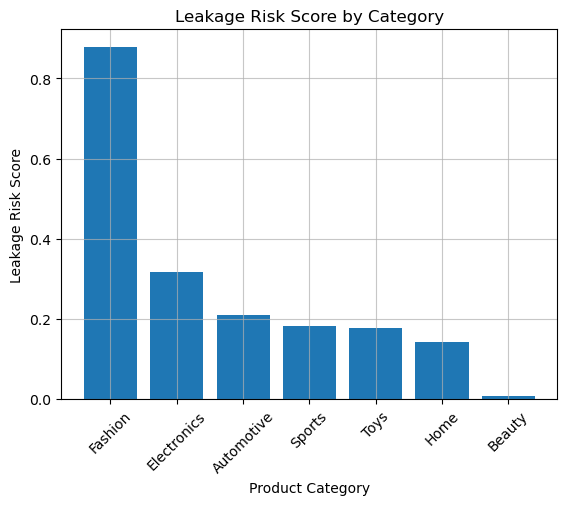

In [127]:
import matplotlib.pyplot as plt

risk_sorted = final_category.sort_values(
    by='leakage_risk_score',
    ascending=False
)

plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.bar(risk_sorted['product_category'],
       risk_sorted['leakage_risk_score'])
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Leakage Risk Score")
plt.title("Leakage Risk Score by Category")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 2 — Profit Margin by Category
-

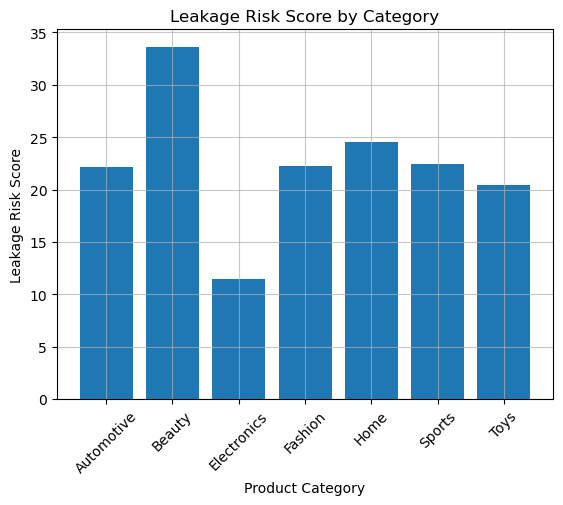

In [128]:
plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.bar(cat_pro['product_category'],
       cat_pro['profit_margin_%'])
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Leakage Risk Score")
plt.title("Leakage Risk Score by Category")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 3 — Return Rate by Category
-

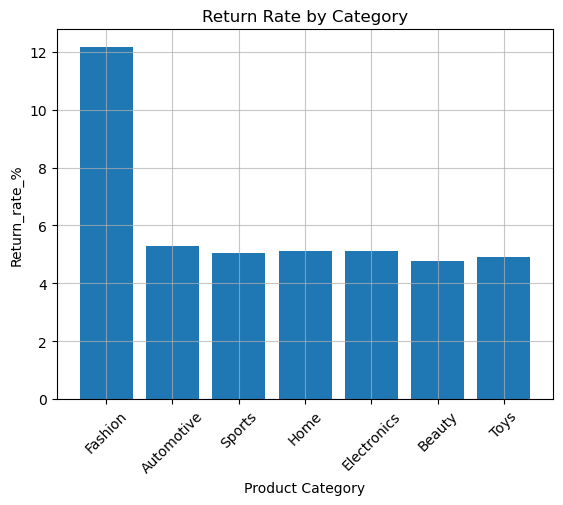

In [129]:
plt.figure
with plt.style.context('_classic_test_patch'):
    plt.bar(category_analysis['product_category'],
           category_analysis['return_rate_%'])
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Return_rate_%")
plt.title("Return Rate by Category")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 5 — Monthly Return Rate Trend
-

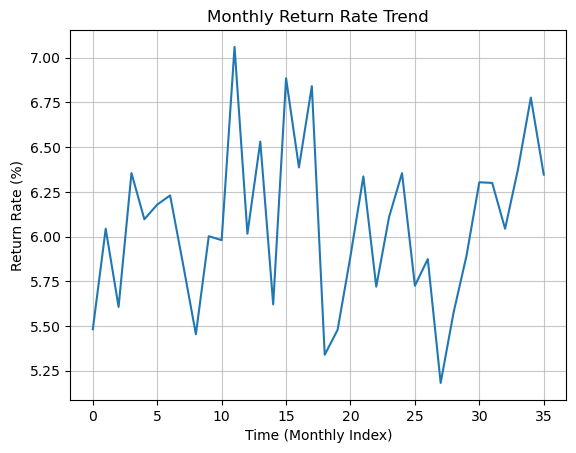

In [130]:
plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.plot(month_analysis['return_rate_%'])
plt.xlabel("Time (Monthly Index)")
plt.ylabel("Return Rate (%)")
plt.title("Monthly Return Rate Trend")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 6 — Profit Loss by Category
-

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\1018140332.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_loss_table = df[df['is_returned'] == 1].groupby(


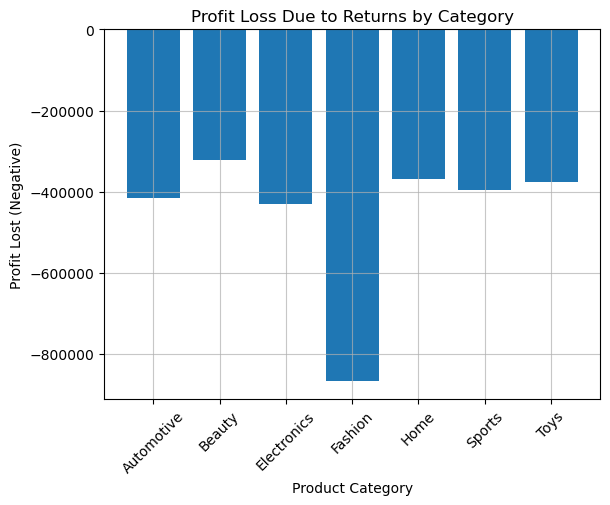

In [133]:
profit_loss_table = df[df['is_returned'] == 1].groupby(
    'product_category'
)['profit'].sum().reset_index()

plt.figure()
with plt.style.context('_classic_test_patch'):
   plt.bar(profit_loss_table['product_category'],
        profit_loss_table['profit'])

plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Profit Lost (Negative)")
plt.title("Profit Loss Due to Returns by Category")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 7 — Revenue Loss by Region
-

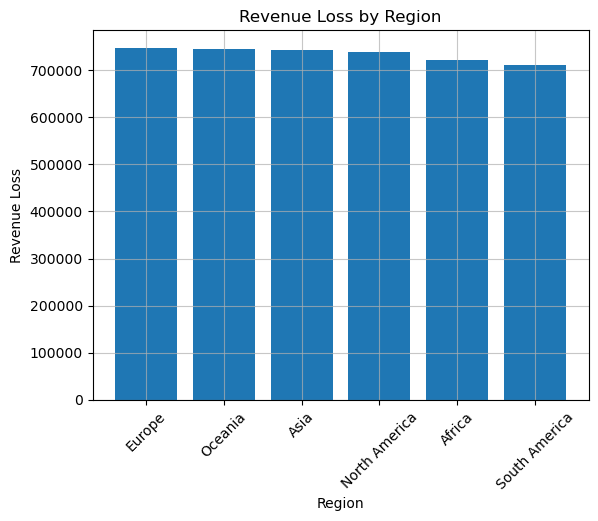

In [134]:
plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.bar(region_table['region'],
           region_table['revenue_loss'])
plt.xticks(rotation=45)
plt.xlabel("Region")
plt.ylabel("Revenue Loss")
plt.title("Revenue Loss by Region")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 8 — Return Rate by Region
-

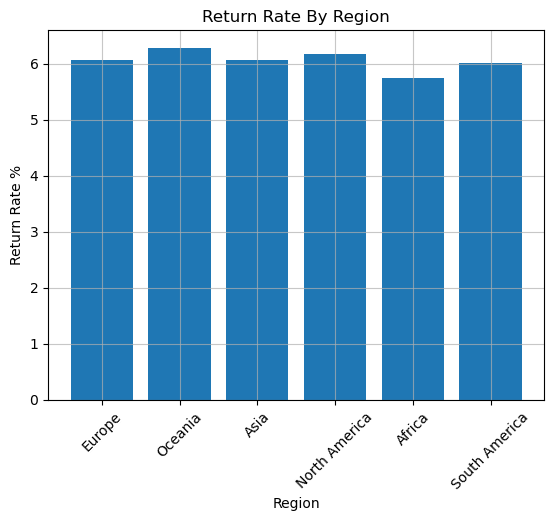

In [135]:
plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.bar(region_table['region'],
           region_table['return_rate_%'])
plt.xticks(rotation=45)
plt.xlabel("Region")
plt.ylabel("Return Rate %")
plt.title("Return Rate By Region")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 9 — Profit Margin vs Return Rate (Risk Quadrant)
-

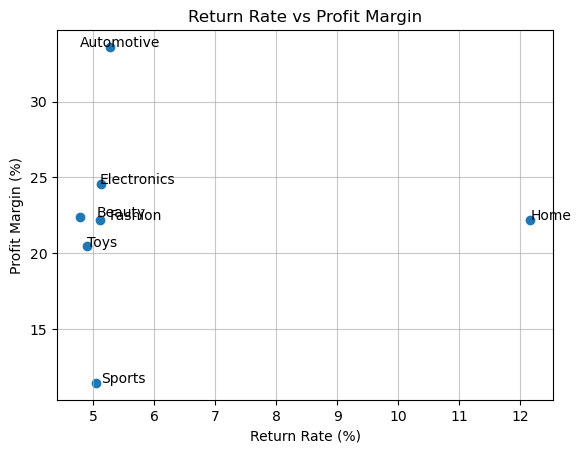

In [141]:
plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.scatter(category_analysis['return_rate_%'],
            cat_pro['profit_margin_%'])

for i, txt in enumerate(category_analysis['product_category']):
    plt.annotate(txt,
                 (category_analysis['return_rate_%'][i],
                  cat_pro['profit_margin_%'][i]))

plt.xlabel("Return Rate (%)")
plt.ylabel("Profit Margin (%)")
plt.title("Return Rate vs Profit Margin")
plt.grid(True,alpha=0.7)
plt.show()

VISUAL 10 — Category × Region Revenue Loss Heatmap
-

In [144]:
#create a pivot data
heatmap_data = df.pivot_table(
    values='revenue_loss',
    index='product_category',
    columns='region',
    aggfunc='sum'
)

C:\Users\nagat\AppData\Local\Temp\ipykernel_15300\543387208.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(


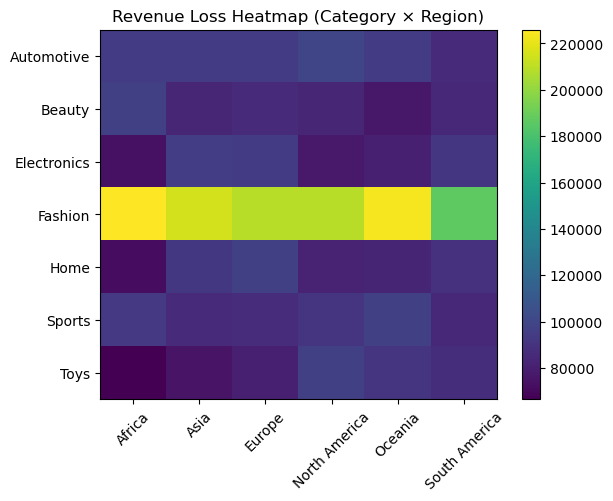

In [145]:
plt.figure()
with plt.style.context('_classic_test_patch'):
        plt.imshow(heatmap_data, aspect='auto')

plt.xticks(np.arange(len(heatmap_data.columns)),
           heatmap_data.columns, rotation=45)
plt.yticks(np.arange(len(heatmap_data.index)),
           heatmap_data.index)

plt.colorbar()
plt.title("Revenue Loss Heatmap (Category × Region)")

plt.show()

VISUAL 11 — Discount vs Return Scatter
-

In [146]:
discount_return = df.groupby('discount_percent').agg(
    total_orders=('order_id','count'),
    returned_orders=('is_returned','sum')
).reset_index()

discount_return['return_rate_%'] = (
    discount_return['returned_orders'] /
    discount_return['total_orders']
) * 100

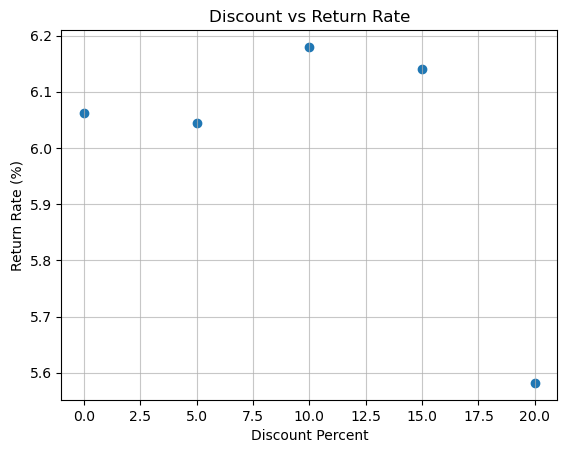

In [148]:
plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.scatter(discount_return['discount_percent'],
            discount_return['return_rate_%'])

plt.xlabel("Discount Percent")
plt.ylabel("Return Rate (%)")
plt.title("Discount vs Return Rate")
plt.grid(True,alpha=0.7)
plt.show()


VISUAL 12 — Correlation Heatmap
-

In [152]:
numeric_df = df[['product_price','quantity',
                 'discount_percent','delivery_days',
                 'customer_rating','net_revenue',
                 'profit']]

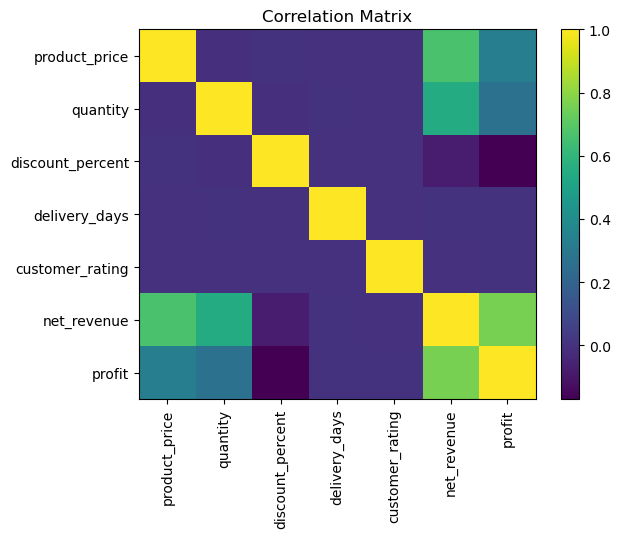

In [155]:
corr = numeric_df.corr()

plt.figure()
with plt.style.context('_classic_test_patch'):
    plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr.columns)),
           corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.colorbar()
plt.title("Correlation Matrix")
plt.show()